# FINM3422 - Project 3

### Market Data and Yield Curve Anlaysis Notebook
---
**Course**: FINM3411 - Financial Modelling

**Group Members**:
1. Gene Wu
2. Patrick Liu
3. Alex Apelt
4. Rohith Porthugunta

**Due**: Friday 29 May 2026, 4:00pm AEST

**AI Usage**: Code structure and docstrings assisted by Claude (Anthropic)

----

### **Section 1: Notebook Setup and Data Loading**

#### 1.1 Import Required Libraries and Project Modules

In [18]:
# Import general data-anlays libraries (numpy, panadas, yfinance, scipy etc.)
# Import plotting libraries (matplotlib etc.)
# IMport file-path management tools
# Import any custom python files, modules that are only needed for this notebook from the scr/ folder

# Standard imports
import sys
import os
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import warnings
warnings.filterwarnings('ignore')

# Add project root to path so src modules are importable
sys.path.insert(0, os.path.abspath('..'))

# Project modules
from data_loader import (
    run_full_pipeline, load_equity_prices, load_yield_curve_data,
    PORTFOLIO_TICKERS, EQUITY_START, EQUITY_END,
)
from yieldcurve import YieldCurve

# Chart styling
plt.rcParams.update({
    'figure.dpi':         120,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'font.size':          11,
})

# Constants
TICKER_LABELS = {
    'CBA.AX': 'Commonwealth Bank',
    'WOW.AX': 'Woolworths',
    'BHP.AX': 'BHP Group',
    'CSL.AX': 'CSL Limited',
}
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# Output directories
FIG_DIR  = os.path.abspath(os.path.join('..', 'outputs', 'figures'))
os.makedirs(FIG_DIR, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [28]:
# Load data
from pathlib import Path

# Go from notebook folder → project root → data folder
DATA_DIR = Path.cwd().parent / "data"
FIG_DIR  = Path.cwd().parent / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR  = Path.cwd().parent / "outputs" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

result = run_full_pipeline(
    tickers       = PORTFOLIO_TICKERS,
    start         = EQUITY_START,
    end           = EQUITY_END,
    force_refresh = False,
)

prices       = result['prices']        # Daily Close prices DataFrame
returns      = result['returns']       # Daily log returns DataFrame
volatilities = result['volatilities']  # Annualised volatility Series
correlation  = result['correlation']   # Correlation matrix DataFrame
yield_curve  = result['yield_curve']   # 7-point RBA yield curve DataFrame

print(f"\nSample period: {prices.index[0].strftime('%b %Y')} — {prices.index[-1].strftime('%b %Y')}")
print(f"Trading days : {len(prices)}")
print(f"Tickers      : {list(prices.columns)}")

[DataLoader] Starting full data pipeline...
[DataLoader] Loading equity prices from cache: equity_prices_raw.csv
[DataLoader] Loading log returns from cache: equity_returns.csv
[DataLoader] Loading volatility from cache: equity_volatility.csv
[DataLoader] Loading correlation matrix from cache: correlation_matrix.csv
[DataLoader] Loading yield curve from cache: yield_curve_processed.csv

[DataLoader] ✓ Full pipeline complete.
  Tickers      : ['CBA.AX', 'WOW.AX', 'BHP.AX', 'CSL.AX']
  Date range   : 2022-01-01 → 2025-12-31
  Trading days : 1009


Sample period: Jan 2022 — Dec 2025
Trading days : 1009
Tickers      : ['CBA.AX', 'WOW.AX', 'BHP.AX', 'CSL.AX']


#### 1.2 Chart Styling and Display Settings

In [2]:
# Set default chart size, grid/chart style
# Set decimal display format for tables
# Set maximum columns/rows dislayed for data tables

#### 1.3 Load Equity Price Data

In [21]:
# =============================================================================
# 1.3 Load Equity Price Data
# =============================================================================
# Load historical price data for CBA.AX, BHP.AX, CSL.AX, WOW.AX via yfinance API
# data_loader.run_full_pipeline() fetches adjusted closing prices from yfinance,
# caches them to data/processed/equity_prices.csv, and returns them as `prices`.
# Adjusted prices account for dividends and stock splits.

# Confirm dates are correctly recognised as DatetimeIndex
assert isinstance(prices.index, pd.DatetimeIndex), "Index is not DatetimeIndex."

# Confirm date is set as the index and observations are sorted oldest → newest
assert prices.index.is_monotonic_increasing, "Prices are not sorted by date."

# Confirm all four tickers are present
assert set(PORTFOLIO_TICKERS).issubset(prices.columns), "Missing tickers in price data."

# Display the first few rows to confirm loading worked
print(f"Equity prices loaded:  {prices.shape[0]} trading days  |  {prices.shape[1]} tickers")
print(f"Date range:            {prices.index[0].strftime('%d %b %Y')} — {prices.index[-1].strftime('%d %b %Y')}")
print(f"Columns (tickers):     {list(prices.columns)}\n")

prices.head()

Equity prices loaded:  1009 trading days  |  4 tickers
Date range:            04 Jan 2022 — 30 Dec 2025
Columns (tickers):     ['CBA.AX', 'WOW.AX', 'BHP.AX', 'CSL.AX']



,CBA.AX,WOW.AX,BHP.AX,CSL.AX
Date,,,,
2022-01-04,87.162369,33.571617,28.351421,275.898010
2022-01-05,87.749054,33.039288,28.518663,270.873932
2022-01-06,85.002647,32.664040,28.552111,260.993439
2022-01-07,87.281403,32.602947,29.254547,263.230530
2022-01-10,87.851089,32.376057,29.956974,260.993439


#### 1.4 Load Yield Curve Data

In [22]:
# =============================================================================
# 1.4 Load Yield Curve Data
# =============================================================================
# Load raw yield curve data from the RBA (F1/F2 spreadsheet).
# data_loader.run_full_pipeline() parses the RBA file, caches the cleaned
# 7-point curve to data/processed/yield_curve_processed.csv, and returns
# it as `yield_curve`.

# Confirm required columns are present (maturity in years, rate as decimal)
required_cols = {"maturity_years", "yield", "as_of_date"}
assert required_cols.issubset(yield_curve.columns), \
    f"Missing columns. Expected: {required_cols}, got: {set(yield_curve.columns)}"

# Maturity values are already in years (e.g. 0.0833 = 1 month, 10.0 = 10 years)
# Interest rates are already in decimal format (e.g. 0.0444 = 4.44%)
# Confirm sorted from shortest to longest maturity
assert yield_curve["maturity_years"].is_monotonic_increasing, \
    "Yield curve is not sorted by maturity."

# Display the first few rows to confirm loading worked
print(f"Yield curve loaded:    {len(yield_curve)} maturity points  |  as-of {yield_curve['as_of_date'].iloc[0]}")
print(f"Maturity range:        {yield_curve['maturity_years'].min():.4f} yrs — {yield_curve['maturity_years'].max():.0f} yrs")
print(f"Rate range:            {yield_curve['yield'].min():.4%} — {yield_curve['yield'].max():.4%}\n")

yield_curve.head(10)

Yield curve loaded:    7 maturity points  |  as-of 2026-05-13
Maturity range:        0.0833 yrs — 10 yrs
Rate range:            4.2900% — 5.0660%



,maturity_years,yield,as_of_date
0,0.0833,0.04290,2026-05-13
1,0.2500,0.04440,2026-05-13
2,0.5000,0.04800,2026-05-13
3,2.0000,0.04740,2026-05-13
4,3.0000,0.04717,2026-05-13
5,5.0000,0.04753,2026-05-13
6,10.0000,0.05066,2026-05-13


#### 1.5 Initial Data Checks and Validation

In [26]:
# For equity data:
    # Check number of observations
    # Check start date and end date
    # Check for missing values
    # Check for duplicated dates
    # Check whether all four tickers are present
    # Check whether prices are numberic
    # Remove or handle missing values if needed

# --- Equity data ---
print("Equity Price Data:")
print(f"  Observations     : {len(prices)}")
print(f"  Start date       : {prices.index[0].strftime('%d %b %Y')}")
print(f"  End date         : {prices.index[-1].strftime('%d %b %Y')}")
print(f"  Tickers present  : {list(prices.columns)}")
print(f"  Numeric prices   : {all(pd.api.types.is_numeric_dtype(prices[c]) for c in prices.columns)}")
print(f"  Duplicated dates : {prices.index.duplicated().sum()}")
print("  Missing values:")
print(prices.isna().sum().to_string())

# Remove or handle missing values if needed
missing = prices.isna().sum().sum()
if missing > 0:
    prices = prices.ffill().bfill()
    print(f"\n[Warning] {missing} missing value(s) filled via ffill/bfill.")
else:
    print("\nAll clear — no missing values.")

# For yield curve raw data:
    # CHeck number of maturity observations
    # Check minimum and maxmimum maturity
    # Check for missing values
    # Check for duplicated maturities
    # Check whether the rates are numeric
    # Check if the maturities are sortec correctly

# --- Yield curve raw data ---
print("\nYield Curve Data:")
print(f"  Maturity points  : {len(yield_curve)}")
print(f"  Min maturity     : {yield_curve['maturity_years'].min():.4f} yrs")
print(f"  Max maturity     : {yield_curve['maturity_years'].max():.0f} yrs")
print(f"  Sorted correctly : {yield_curve['maturity_years'].is_monotonic_increasing}")
print(f"  Duplicated rows  : {yield_curve['maturity_years'].duplicated().sum()}")
print(f"  Missing values   : {yield_curve[['maturity_years','yield']].isna().sum().sum()}")
print("\nAll clear — no missing values.")

Equity Price Data:
  Observations     : 1009
  Start date       : 04 Jan 2022
  End date         : 30 Dec 2025
  Tickers present  : ['CBA.AX', 'WOW.AX', 'BHP.AX', 'CSL.AX']
  Numeric prices   : True
  Duplicated dates : 0
  Missing values:
CBA.AX    0
WOW.AX    0
BHP.AX    0
CSL.AX    0

All clear — no missing values.

Yield Curve Data:
  Maturity points  : 7
  Min maturity     : 0.0833 yrs
  Max maturity     : 10 yrs
  Sorted correctly : True
  Duplicated rows  : 0
  Missing values   : 0

All clear — no missing values.


---

### **Section 2: Equity Market Overview**

- Discuss that the selected equities represent different sectors of the Australian equity market
- Explain why the selected equities represent diversified exposure across different sectors of the Australian economy and discuss how sector diversification reduces concentration risk by ensuring that portfolio performance is not entirely dependent on a single industry or macroeconomic driver.

- State the portfolio will contain 4 equities from a range of sector markets to ensure diversification
- Explain how combining cyclical and  equities improves portfolio diversification because different sectors may outperform or underperform during different market environments, reducing the likelihood that all portfolio positions decline simultaneously.
- Discuss how differing sector exposures create varying return and volatility profiles across the portfolio, which becomes important later when analysing portfolio risk, derivative overlays, and hedging effectiveness.
- Explain that the selected equity universe establishes the foundation for later derivative pricing and portfolio analysis because differing volatility characteristics, growth behaviour, and downside-risk profiles influence option sensitivity, derivative valuation, and portfolio-risk exposure.

[write here]

#### 2.1 Equity Universe and Sector Exposure

In [6]:
# Table 1 = Equity Universe Overview Table --> columns = equity, ticker, sector, current markert exposure, key characteristics

**Interpretation: Equity Selection and Sector Diversification**

- Discuss the economic characteristics of each sector individually and explain how different sectors respond differently to changing economic conditions, interest rates, inflation expectations, commodity prices, and consumer demand conditions.

- Explain that financial sector equities such as CBA are highly influenced by economic growth, lending activity, consumer confidence, and interest-rate conditions, meaning that banking-sector performance is often strongly linked to the broader business cycle.
- Discuss how materials/mining sector equities such as BHP are cyclical in nature and highly sensitive to global commodity demand, industrial production, and international economic activity, which may lead to stronger volatility and larger price swings during changing macroeconomic conditions.
- Explain that healthcare equities such as CSL may exhibit relatively defensive demand characteristics because healthcare services remain important regardless of economic conditions, although growth-oriented healthcare firms may still exhibit valuation sensitivity due to investor expectations regarding future earnings growth.
- Discuss how consumer staples equities such as WOW generally exhibit more stable demand because consumers continue purchasing essential goods during both economic expansions and downturns, potentially resulting in more stable earnings and lower share-price volatility.

- Discuss how differing sector exposures create varying return and volatility profiles across the portfolio, which becomes important later when analysing portfolio risk, derivative overlays, and hedging effectiveness.

[analyse here]

#### 2.2 Equity Price and Historical Returns Analysis

- Discuss the importance of historical price analysis and how it provides insight into market behaviour and peformance
- Explain how historical price analysis provides insight into underlying market behaviour and helps identify whether equities exhibit stable, cyclical, defensive, or growth-oriented characteristics.

- Explain the methodology behind how the historical returns are calculated
- Discuess why returns are important by discussing how it provides a more meaningful comparison than raw prices and how it supports volatility estimation, risk modelling, portfolio analysis etc.

[write here]

In [7]:
# Calculate historical stock prices
# Calculate daily returns (normal or log returns)

# Create equity market overview table (columns = stock, start price, end price, total %return, average daily return, annualised return)

# Graph 1 = Historical Price Series Plot --> x-axis = time, y-axis = stock price (this is to visualise long-tern historical stock price behaviour)
# Graph 2 = Normalised Price Comparison Plot --> rebase all stocks to 100 to allow for consistent comparison of relative performance
# Graph 3 = Daily Returns Time-Series Plot --> x-axis = date, y-axis = daily returns

# Save all figures

**Interpretation: Historical Price Series Trend Analysis**

- Discuss the overall long-term price trend observed for each equity and explain whether each stock demonstrates sustained appreciation, prolonged decline, cyclical fluctuations, or relatively stable growth throughout the dataset period.
- Discuss whether price appreciation appears gradual or highly unstable and explain how smoother appreciation may indicate more stable investor expectations and lower market uncertainty.
- Identify major periods of upward and downward movement and explain how these movements may reflect changing investor sentiment, economic conditions, earnings expectations, interest-rate changes, commodity-price movements, or broader market shocks.
- Discuss whether certain equities appear more resilient during market downturns and explain how defensive sectors may preserve value more effectively during stressed economic conditions due to more stable earnings and consumer demand.
- Analyse whether any equities exhibit prolonged sideways/range-bound behaviour and discuss how this may indicate lower growth expectations, defensive market characteristics, or mature sector behaviour.

- Explain how cyclical sectors may experience larger drawdowns during periods of economic slowdown because investor expectations regarding future growth and profitability become more uncertain during weaker economic conditions.
- Analyse whether the equities experienced synchronized market movements during major market events and discuss whether broader market conditions appear to affect all equities simultaneously or whether certain sectors behaved differently during stressed periods.
- Discuss differences in long-term growth behaviour across equities and explain how growth-oriented equities may exhibit stronger appreciation potential but also greater price sensitivity and higher volatility.

[analyse here]

**Interpretation: Relative Perfomance Comparison Analysis**

- Explain why normalized price analysis is important by discussing how rebasing all equities to a common starting value allows direct comparison of percentage performance regardless of differing absolute stock-price levels.
- Discuss which equities outperformed or underperformed over the dataset period and explain how stronger relative performance may reflect superior earnings growth, stronger sector conditions, higher investor confidence, or favourable macroeconomic trends.
- Compare the magnitude of cumulative growth across equities and discuss whether differences in long-term performance appear economically significant or relatively minor.
- Analyse whether certain equities consistently outperform throughout the entire dataset or only during specific market environments and explain how this may reflect differing economic sensitivities.
- Analyse the consistency of performance across time and explain whether certain equities exhibit smoother and more stable long-term appreciation while others experience larger fluctuations and cyclical behaviour.

- Discuss how cyclical equities may experience periods of rapid appreciation during strong economic conditions but also sharper declines during economic slowdowns due to changing growth expectations and investor risk appetite.
- Explain how defensive equities may demonstrate more stable cumulative growth because demand for their products or services remains relatively stable across differing economic conditions.
- Analyse recovery behaviour following market downturns and explain how faster recovery may indicate stronger investor confidence, resilient earnings expectations, and lower perceived downside risk.
- Discuss whether any equities exhibit stronger downside persistence following market downturns and explain how this may indicate prolonged investor pessimism or weaker sector recovery conditions.

[analyse here]

**Interpretation: Daily Return Time-Series Analysis**

- Discuss the presence of volatility clustering by explaining how periods of elevated return volatility tend to occur together rather than randomly, indicating that market instability is persistent rather than constant through time.
- Discuss whether daily return behaviour appears relatively predictable/stable or highly unstable and explain how this affects market-risk expectations.
- Analyse the frequency and magnitude of extreme positive and negative daily returns and explain how large return movements often occur during periods of financial stress, earnings announcements, unexpected economic information, or broader market uncertainty.
- Discuss whether certain equities exhibit larger return dispersion and explain how wider fluctuations in returns generally imply greater market uncertainty, stronger cyclical sensitivity, or higher risk exposure.

- Analyse whether large positive and negative return observations occur symmetrically or whether downside movements appear larger and more frequent than upside movements.
- Explain why downside return observations are especially important because large negative returns contribute significantly to portfolio downside risk and later risk-management analysis.
- Discuss whether periods of elevated return volatility appear concentrated around specific market events or whether instability appears persistent across the entire dataset period.

- Analyse whether certain equities exhibit more frequent extreme return observations and explain how this may indicate stronger sensitivity to changing macroeconomic conditions or investor sentiment.
- Discuss how periods of elevated return instability may later affect volatility estimation, derivative pricing, Value-at-Risk modelling, and stress-testing analysis.
- Explain how return behaviour analysis provides insight into the stability and predictability of equity performance and helps identify whether market behaviour is relatively stable or highly unstable across time.

[analyse here]

#### 2.3 Volatility and Risk Behaviour Analysis

- Explain the importance of volatility by discussing how it measures uncertainty and financial risk
- Explain why time-varying volatility is important for financial modelling because many simplified financial models assume constant volatility despite real financial markets exhibiting changing risk conditions.

- Explain the relationship between volatility and risk (higher volatility = greater porfolio uncertainty = greater downside exposure)
- Discuss how elevated volatility directly affects portfolio risk exposure and later influences derivative pricing, option premiums, Value-at-Risk estimates, and stress-testing outcomes.


[write here]

In [8]:
# Calculate daily and annualised volatility
# Calculate 30-day rolling volatility
# Calculate downside return metrics (minimum return, downside deviation, worst daily loss)

# Table 1 = Volatility and Risk Summary Table --> columns = equity, daily volatility, annualised volatility, downaide deviation, worst daily return

# Graph 1 = 30-day Rolling Volatility Plot (for all equities) --> x-axis = date, y-axis = rolling volatility
# Graph 2 = VOlatility Comparison Bar Chart (across all equities)
# Graph 3 = Return Boxplot

# Save all figures

**Interpretation: Rolling Volatility Plot Analysis**

- Discuss how rolling volatility analysis demonstrates that market risk changes dynamically through time rather than remaining constant, reflecting changing economic conditions, investor sentiment, and market uncertainty.
- Identify periods of elevated rolling volatility and explain how these periods are often associated with financial stress, economic uncertainty, declining investor confidence, macroeconomic shocks, or heightened market instability.
- Explain the concept of volatility clustering by discussing how periods of high volatility tend to persist because uncertainty shocks and investor reactions often continue across multiple trading periods.

- Analyse whether volatility spikes occur simultaneously across all equities and discuss whether broader market-wide instability appears to affect the entire portfolio during stressed market conditions.
- Discuss whether certain equities recover more quickly following periods of elevated volatility and explain how faster volatility normalization may indicate stronger market stability or lower perceived uncertainty.
- Analyse whether volatility remains persistently elevated for certain equities and explain how prolonged instability may reflect sustained uncertainty regarding sector conditions or future earnings expectations.
- Discuss whether defensive equities exhibit smaller volatility spikes during stressed market periods and explain how stable earnings expectations and lower cyclical exposure may contribute to reduced market instability.

[analyse here]

**Interpretation: Comparative Volatility Bar Chart Analysis**

- Compare annualized volatility levels across equities and explain how higher volatility indicates greater uncertainty regarding future returns and stronger potential for large price movements.
- Compare the magnitude differences between annualized volatility levels and discuss whether certain equities appear substantially riskier or only moderately more volatile relative to the rest of the portfolio.

- Analyse whether the volatility rankings align with the expected economic characteristics of each sector and discuss whether higher-risk equities also exhibit greater return variability.
- Analyse whether any equities appear unusually volatile relative to their sector characteristics and discuss potential explanations such as investor sentiment, earnings uncertainty, or market expectations.
- Analyse whether volatility rankings align consistently with the observed historical price behaviour from Section 2.2 and discuss whether the most unstable equities also exhibited the largest price fluctuations and return dispersion.
- Explain the relationship between volatility and downside risk by discussing how higher volatility increases the probability of large negative return observations and greater portfolio uncertainty.
- Discuss how volatility differences across equities influence portfolio construction decisions because highly volatile assets contribute more significantly to total portfolio risk exposure.
- Discuss whether the volatility differences across sectors appear economically reasonable based on each sector’s underlying business and macroeconomic sensitivity.

[analyse here]

**Interpretation: Return Dispersion Boxplot and Outlier Analysis**

- Discuss the overall spread of returns observed in the boxplots and explain how wider dispersion indicates greater uncertainty and stronger variability in equity performance.
- Analyse the relative width of each boxplot and discuss which equities exhibit the largest interquartile return ranges, indicating greater variability in day-to-day market performance.
- Analyse the presence of extreme outlier observations and explain how these observations represent unusually large positive or negative market movements that may occur during periods of financial stress or major economic events.
- Discuss whether downside outliers appear larger or more frequent than upside outliers and explain how this may indicate asymmetric downside-risk exposure.

- Analyse whether outlier observations appear isolated or frequent and explain how repeated extreme observations may indicate persistent market instability rather than occasional shocks.
- Discuss whether certain equities display more concentrated return distributions while others exhibit wider return spread and explain how this reflects differing market-risk characteristics.
- Explain that financial returns often contain extreme observations that exceed normal day-to-day volatility expectations, demonstrating that market behaviour is not perfectly stable or normally distributed.
- Analyse whether certain equities exhibit significantly larger downside observations and explain how this may reflect stronger cyclical exposure, higher investor sensitivity, or greater market uncertainty.
- Discuss why downside outliers are especially important for portfolio-risk management because extreme losses can significantly affect portfolio valuation, Value-at-Risk estimates, and stress-testing outcomes.
- Explain how return dispersion and outlier analysis helps identify which equities contribute most strongly to portfolio downside risk and overall market instability.

[analyse here]

#### 2.4 Return Distribution Analysis

- Explain why understanding return distributions is important because many financial models and risk-management frameworks rely on assumptions regarding distribution shape and tail behaviour.
- Explain the inportance of determining the distribution of returns by discussing how the distibution shape influences portfolio risk behaviour and downside exposure
- Explain that financial returns rarely follow perfect normal distributions because market behaviour is influenced by investor sentiment, unexpected information, macroeconomic shocks, and periods of financial stress.

- Discuss how distribution analysis provides insight into market-risk characteristics beyond simple volatility estimation by analysing the shape and extremity of return behaviour.
- Explain why tail behaviour matters and why they are important for VaR, stress testing, and derivative risk analysis
- Discuss why excess kurtosis is important for financial risk management because standard risk models based on normal distributions may underestimate the likelihood of extreme losses.
- Explain that financial returns rarely follow perfect normal distributions because market behaviour is influenced by investor sentiment, unexpected information, macroeconomic shocks, and periods of financial stress.

[write here]

In [9]:
# Use historical returns data to calculate skewness, kurtosis, maximum/minimu return, 5th percentile return, 95th percentile return

# Table 1 = Return Distributiuon Summary Table (for all equities) --> columns = equity, ticker, skewness, kurtosis, maximum return, minimun return, 5th percentile return, 95th percentile return

# Graph 1 = Return Histogram with a KDE Plot + comparison to normal distribution curve (for all equities) --> purpose is to visualise the overall return distribution shape and also the smooth distribution characteristics

# Save all figures

**Interpretation: Return Histogram and Distribution Shape Analysis**

- Discuss the overall shape of the return distribution and explain whether returns appear approximately symmetric, positively skewed, or negatively skewed.
- Analyse whether the return distributions appear narrow and concentrated or wide and dispersed and discuss how broader distributions indicate greater return variability and market uncertainty.

- Analyse whether the histograms appear approximately symmetric around the mean or whether downside observations appear more pronounced than upside observations.
- Discuss whether the tails of the distributions appear substantially thicker than expected under a normal distribution and explain how this indicates elevated probability of extreme market movements.
- Analyse whether cyclical equities exhibit visibly wider and heavier-tailed distributions relative to defensive equities and explain how stronger macroeconomic sensitivity may contribute to greater return instability.

- Discuss whether negative return observations appear more extreme than positive return observations and explain how this may indicate elevated downside-risk exposure.
- Analyse whether certain equities exhibit stronger asymmetry or heavier tails and explain how this reflects differing market-risk characteristics across sectors.

[analyse here]

**Interpretation: KDE Density Distribution Analysis**

- Compare the smoothness and concentration of the KDE curves across equities and discuss whether certain equities exhibit more stable and concentrated return behaviour while others display wider and flatter distributions.
- Discuss the smooth distribution shape observed in the KDE plots and explain whether returns appear approximately normal or exhibit noticeable skewness and excess kurtosis.
- Discuss whether certain equities exhibit substantially heavier tails relative to others and explain how this reflects differing levels of tail-risk exposure across sectors.

- Analyse whether the KDE curves exhibit visible asymmetry and discuss whether downside-tail behaviour appears more pronounced than upside-tail behaviour.
- Analyse whether the peaks of the KDE distributions appear sharply concentrated or relatively flat and explain how flatter distributions generally indicate greater return variability and uncertainty.
- Explain the concept of skewness by discussing how negative skewness indicates greater probability of severe downside returns while positive skewness suggests stronger upside-tail potential.
- Analyse whether the distributions exhibit excess kurtosis and explain how higher kurtosis indicates increased probability of extreme market movements and elevated tail risk.

- Explain that heavy-tailed distributions imply greater downside-risk exposure because extreme market movements occur more frequently than standard models predict.
- Analyse whether certain equities display stronger non-normality characteristics and explain how cyclical sectors may exhibit heavier tails due to stronger sensitivity to economic shocks and market instability.

[analyse here]

#### 2.5 Correlation and Diversification Analysis

- Explain how correlation analysis is important for portfolio construction because portfolio risk depends not only on individual asset volatility but also on how assets interact with one another.
- Explain the significan of equity correlation in diversification and how lower correlation may reduce overall portfolio risk

- Explain that diversification benefits arise because losses in one asset may be partially offset by stability or gains in another asset with differing market behaviour.
- Discuss how correlation behaviour later influences portfolio-risk modelling, Value-at-Risk estimation, stress testing, and derivative hedging effectiveness throughout the remainder of the project.

[write here]

In [10]:
# Graph 1 = Correlation Matric with Heatmap Visualisation --> this visualises the correlation strength between equities

# Save all figures

**Interpretation: Correlation and Diversification Analysis**

<u> Correlation Magnitude Analysis - </u>

- Discuss the strength and direction of correlations between equities and explain how correlation measures the extent to which asset returns move together through time.
- Identify which equity pairs exhibit the strongest positive correlations and discuss whether these relationships appear economically reasonable based on sector exposure and underlying macroeconomic drivers.

- Analyse which equity pairs exhibit the weakest correlations and discuss how lower co-movement behaviour improves diversification by reducing the likelihood that all equities experience similar return behaviour simultaneously.
- Compare whether cyclical equities appear more strongly correlated with each other relative to defensive equities and explain how shared economic sensitivity may contribute to stronger co-movement behaviour.

<u> Heatmap Structure Analysis - </u>
- Analyse whether the observed correlations appear weak, moderate, or strong overall and discuss what this implies regarding the portfolio’s diversification effectiveness.
- Discuss whether any correlations appear unexpectedly high or unexpectedly low relative to the underlying sector characteristics and explain potential economic reasons for these observations.

- Analyse whether the portfolio appears sufficiently diversified or whether certain equities may contribute concentration risk due to stronger co-movement behaviour.
- Analyse whether the heatmap displays clear clustering behaviour between certain equities and discuss whether these clusters reflect similar sector exposure or macroeconomic sensitivity.
- Discuss whether defensive equities appear less correlated with cyclical equities and explain how this contributes to diversification benefits within the portfolio.
- Analyse whether the overall heatmap structure suggests balanced diversification or whether portions of the portfolio appear highly interconnected.

<u> Portfolio Diversification Quality Analysis - </u>
- Analyse whether the portfolio appears well-diversified overall and explain how combining cyclical and defensive sectors may improve portfolio stability and reduce concentration risk.

- Discuss how correlations may increase during periods of market stress due to panic selling, systemic market risk, and declining investor confidence, potentially weakening diversification benefits during crises.
- Discuss whether the combination of cyclical and defensive sectors appears effective in reducing overall portfolio concentration risk.

[analyse here]

---

### **Section 3: Yield Curve Construction and Interest Rate Modelling**

#### 3.1 Yield Curve Interpolation and Discount Factor Analysis

- Explain that interest rates are an essential input in financial valuation because future cash flows and derivative payoffs must be discounted back to present value using risk-free rates.
- State that this section uses Australian yield curve data extracted from the Reserve Bank of Australia (RBA) dataset to construct a continuous term structure of interest rates across maturities.
- Explain that observed market rates are only available at discrete maturities, therefore interpolation is required to estimate maturity-matched rates for derivative contracts with differing expiration horizons.

- Explain that combining yield curve interpolation and discount-factor modelling provides a consistent interest-rate framework for the valuation of European, American, and barrier option contracts later in the project.
- State that this section constructs the interest-rate framework used later for derivative pricing and valuation.

- Explain how interpolation improves pricing accuracy by generating maturity-matched risk-free rates for derivative valuation.
- Explain why discount factors are important because derivative payoffs must be discounted back to present value during valuation.
- Explain how the interpolated yield curve directly influences discount-factor construction and derivative valuation inputs.

[write here]

In [32]:
# Extract observed maturities and yield/rates from the RBA
# Calculate raw interest rates for each maturity
# Generate a dense maturity grid e.g. create maturioty points between the observed maturities
# Interpolate the yield/interest rates
# Calculate discount factor for each maturity
# Use interpolated yield curve to interpolate discount factor curve

# Table 1 = Interpolated Yield Curve with Disount Factor Table --> column 1 = maturity e.g. 0.5Y/1Y/2Y/5Y/10Y, column 2 = interpolated yield, column 3 = discount factor

# Graph 1 = Raw vs Interpolated Yield Curve vs Discount Plot (line chart + scattered points)

# Save all figures


# ── Generating yield curve summary table ────────────────────────────────────────────────────
yc = YieldCurve()

labels     = ["1m", "3m", "6m", "1y", "2y", "3y", "5y", "7y", "10y"]
maturities = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10])

zero_rates       = yc.get_zero_rate(maturities)
discount_factors = yc.get_discount_factor(maturities)

# Build summary DataFrame
curve_summary = pd.DataFrame({
    "Maturity":        labels,
    "Zero Rate (%)":   zero_rates * 100,
    "Discount Factor": discount_factors,
})

rate_cols = ["Zero Rate (%)"]
df_cols   = ["Discount Factor"]

# Build formatting dictionary
format_dict = {c: "{:.4f}%" for c in rate_cols}
format_dict.update({c: "{:.6f}" for c in df_cols})

# Style and display
summary_table = (
    curve_summary.style
    .hide(axis="index")
    .format(format_dict)
    .set_caption(f"Table ( ): RBA Zero Rate Yield Curve  (as-of {yc.as_of_date})")
    .background_gradient(subset=rate_cols, cmap="Blues")
    .set_table_styles([{"selector": "table", "props": [("width", "100%")]}])
)

display(summary_table)

[YieldCurve] Curve loaded as-of 2026-05-13 | 7 knot points | range: 0.0833–10 yrs


Maturity,Zero Rate (%),Discount Factor
1m,4.2900%,0.996431
3m,4.4400%,0.988961
6m,4.8000%,0.976286
1y,5.1267%,0.950025
2y,4.7400%,0.909555
3y,4.7170%,0.868046
5y,4.7530%,0.788479
7y,4.8139%,0.713929
10y,5.0660%,0.602541


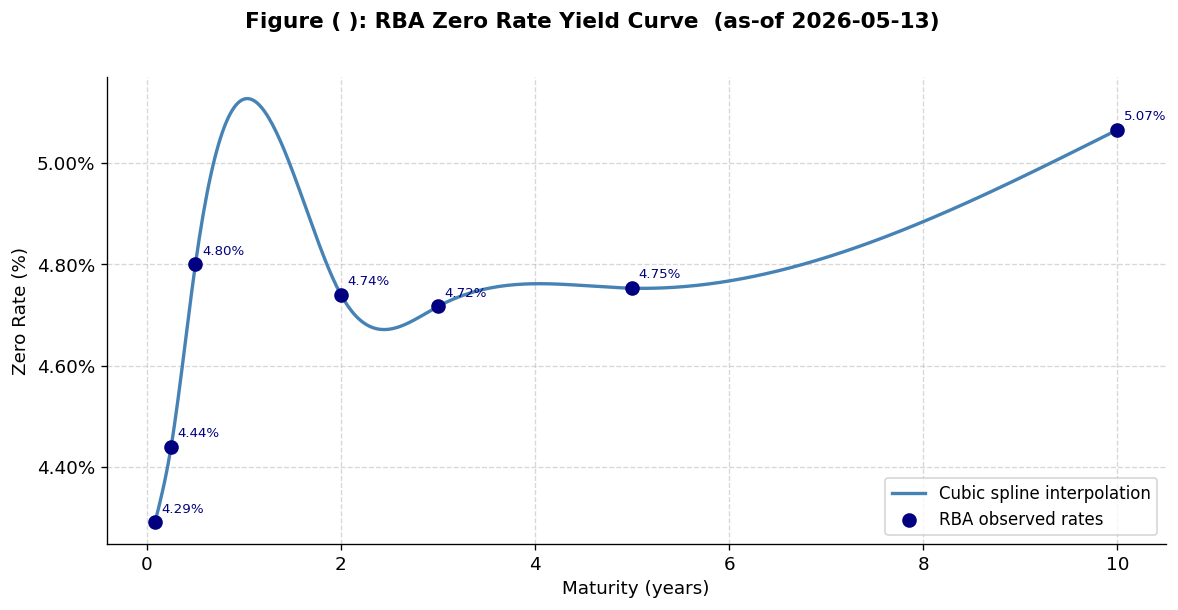

Figure 1 saved.


In [30]:
# ── Plotting yield curve graph ────────────────────────────────────────────────────
# --- Figure 1: RBA Zero Rate Yield Curve ---
fig, ax = plt.subplots(figsize=(10, 5))

# ── Generate smooth interpolated curve data ───────────────────────────────────
t_dense = np.linspace(yc.maturities[0], yc.maturities[-1], 500)
r_dense = yc.get_zero_rate(t_dense) * 100

ax.plot(t_dense, r_dense,
        color="steelblue", linewidth=2, label="Cubic spline interpolation")

ax.scatter(yc.maturities, yc.yields * 100,
           color="navy", zorder=5, s=60, label="RBA observed rates")

for t, r in zip(yc.maturities, yc.yields * 100):
    ax.annotate(f"{r:.2f}%", xy=(t, r), xytext=(4, 6),
                textcoords="offset points", fontsize=8, color="navy")

ax.set_xlabel("Maturity (years)", fontsize=11)
ax.set_ylabel("Zero Rate (%)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle(f"Figure ( ): RBA Zero Rate Yield Curve  (as-of {yc.as_of_date})",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_yield_curve.png", bbox_inches="tight", dpi=150)
plt.show()
print("Figure 1 saved.")

**Interpretation: Yield Curve, Interpolation, and Discount Factor Analysis**

<u> Yield Curve and Interpolation Analysis - </u>

- Discuss the overall shape of the interpolated yield curve and explain whether rates generally increase, decrease, or remain relatively stable across maturities.
- Analyse whether the interpolated curve follows the observed market data smoothly and discuss whether the interpolation appears economically reasonable.

- Discuss whether any maturity regions exhibit sharper changes and explain how this may reflect differing market expectations or gaps between observed maturities.
- Analyse the shape of the yield curve e.g. does it appear upward/downward sloping, flat/curver etc.
- Discuss what the shape of the curve may imply about market expectation and economic conditions
- Analyse the differences between short-term and long-term rates


<u> Discount Factor Curve Analysis </u>

- Discuss how discount factors decline as maturity increases due to the time value of money and present-value discounting.
- Explain the inverse relationship between interest rates and discount factors by discussing how higher yields produce lower present values for future cash flows.

- Analyse whether longer maturities exhibit stronger discounting effects and explain how longer-dated derivative payoffs become more sensitive to discounting.
- Discuss how discount factors decline as maturity increase due to TV of money
- Explain inverse relationship between interest rates and discount factors
- Analyse how higher long-term interest rates reduce the present value of future cashflows


<u> Combined Yield Curve and Discount Factor Relationship Analysis </u>

- Analyse how the combined graph demonstrates the relationship between maturity, interest rates, and present-value discounting within a single framework.

- Discuss whether higher yields correspond to steeper declines in discount factors and explain how this reflects stronger discounting intensity.


[analyse here]

---

### **Section 4: Export Market Inputs**

In [12]:
# Export historical equity returns to "equity_returns.csv" --> export daily returns for each equity
# Export volatility metrics to "equity_volatility.csv" --> export daily volatility, annualised volatility, downside deviation, worst daily return for each equity
# Export correlation matrix to "correlation_matrix.csv" --> export equity return correlation matrix for portfolio construction and diversification analysis
# Export processed yield curve data to "yield_curve_processed.csv" --> export interpolated yield, discount factor for each maturity